# **K Nearest Neighbor - Practice Lab**


Estimated time needed: **30** minutes


In this lab, you will learn about and practice the K Nearest Neighbor (KNN) model. KNN is a straightforward but very effective model that can be used for both classification and regression tasks. If the feature space is not very large, KNN can be a high-interpretable model because you can explain and understand how a prediction is made by looking at its nearest neighbors.


We will be using a tumor sample dataset containing lab test results about tumor samples. The objective is to classify whether a tumor is malicious (cancer) or benign. As such, it is a typical binary classification task.


## Objectives


After completing this lab, you will be able to:


* Train KNN models with different neighbor hyper-parameters
* Evaluate KNN models on classification tasks
* Tune the number of neighbors and find the optimized one for a specific task


----


First, let's install `seaborn` for visualization tasks and import required libraries for this lab.


In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
# Evaluation metrics related methods
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, precision_recall_fscore_support, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

## Load and explore the tumor sample dataset


We first load the dataset `tumor.csv` as a Pandas dataframe:


In [2]:
# Read datast in csv format
# dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/tumor.csv"
tumor_df = pd.read_csv("data/tumor.csv")

Then, let's quickly take a look at the head of the dataframe.


In [3]:
tumor_df.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


And, display its columns.


In [4]:
tumor_df.columns

Index(['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc',
       'BlandChrom', 'NormNucl', 'Mit', 'Class'],
      dtype='str')

Each observation in this dataset contains lab test results about a tumor sample, such as clump or shapes. Based on these lab test results or features, we want to build a classification model to predict if this tumor sample is malicious (cancer) or benign. The target variable `y` is specified in the `Class` column.


Then, let's split the dataset into input `X` and output `y`:


In [5]:
X = tumor_df.iloc[:, :-1]
y = tumor_df.iloc[:, -1:]

And, we first check the statistics summary of features in `X`:


In [6]:
X.describe()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


As we can see from the above cell output, all features are numeric and ranged between 1 to 10. This is very convenient as we do not need to scale the feature values as they are already in the same range.


Next, let's check the class distribution of output `y`:


In [7]:
y.value_counts(normalize=True)

Class
0        0.650073
1        0.349927
Name: proportion, dtype: float64

<Axes: xlabel='Class'>

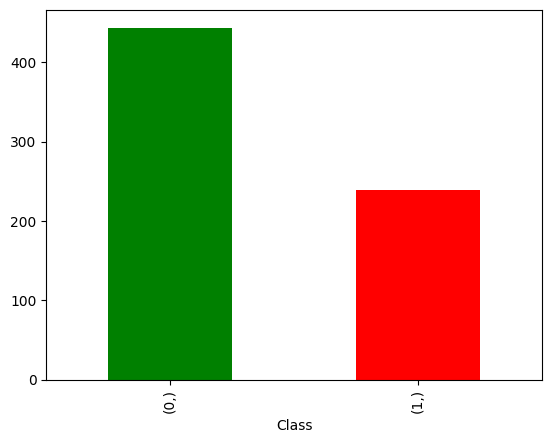

In [8]:
y.value_counts().plot.bar(color=['green', 'red'])

We have about 65% benign tumors (`Class = 0`) and 35% cancerous tumors (`Class = 1`), which is not a very imbalanced class distribution. 


## Split training and testing datasets


In [9]:
# Split 80% as training dataset
# and 20% as testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = 42)

## Train and evaluate a KNN classifier with the number of neighbors set to 2


Training a KNN classifier is very similar to training other classifiers in `sklearn`, we first need to define a `KNeighborsClassifier` object. Here we use `n_neighbors=2` argument to specify how many neighbors will be used for prediction, and we keep other arguments to be their default values.


In [10]:
# Define a KNN classifier with `n_neighbors=2`
knn_model = KNeighborsClassifier(n_neighbors=2)

Then we can train the model with `X_train` and `y_train`, and we use ravel() method to convert the data frame `y_train` to a vector.


In [11]:
knn_model.fit(X_train, y_train.values.ravel())

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


And, we can make predictions on the `X_test` dataframe.


In [12]:
preds = knn_model.predict(X_test)

To evaluate the KNN classifier, we provide a pre-defined method to return the commonly used evaluation metrics such as accuracy, recall, precision, f1score, and so on, based on the true classes in the 'y_test' and model predictions.


In [13]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp, average='binary')
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

In [14]:
evaluate_metrics(y_test, preds)

{'accuracy': 0.9416058394160584,
 'recall': 0.9166666666666666,
 'precision': 0.9166666666666666,
 'f1score': 0.9166666666666666}

We can see that there is a great classification performance on the tumor sample dataset. This means the KNN model can effectively recognize cancerous tumors.
Next, it's your turn to try a different number of neighbors to see if we could get even better performance.


## Coding exercise: Train and evaluate a KNN classifier with number of neighbors set to 5


First, define a KNN classifier with KNeighborsClassifier class:


In [15]:
model = KNeighborsClassifier(n_neighbors=5)


Then train the model with `X_train` and `y_train`:


In [16]:
model.fit(X_train, y_train.values.ravel())


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


And, make predictions on `X_test` dataframe:


In [17]:
preds = model.predict(X_test)

At last, you can evaluate your KNN model with provided `evaluate_metrics()` method.


In [18]:
evaluate_metrics(y_test, preds)

{'accuracy': 0.9562043795620438,
 'recall': 0.9583333333333334,
 'precision': 0.92,
 'f1score': 0.9387755102040817}

## Tune the number of neighbors to find the optmized one


OK, you may wonder which `n_neighbors` argument may give you the best classification performance. We can try different `n_neighbors` (the K value) and check which `K` gives the best classification performance.


Here we could try K from 1 to 50, and store the aggregated `f1score` for each k into a list.


In [19]:
# Try K from 1 to 50
max_k = 50
# Create an empty list to store f1score for each k
f1_scores = []

Then we will train 50 KNN classifiers with K ranged from 1 to 50.


In [24]:
for k in range(1, max_k + 1, 2):
    # Create a KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    # Train the classifier
    knn = knn.fit(X_train, y_train.values.ravel())
    preds = knn.predict(X_test)
    # Evaluate the classifier with f1score
    f1 = f1_score(preds, y_test)
    f1_scores.append((k, round(f1_score(y_test, preds), 4)))
# Convert the f1score list to a dataframe
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])
f1_results.set_index('K')

,F1 Score
K,
1,0.9388
3,0.9278
5,0.9388
7,0.9388
9,0.9388
11,0.9388
13,0.9388
15,0.9495
17,0.9388


This is a long list and difficult to analyse, so let's visualize the list using a linechart.


[]

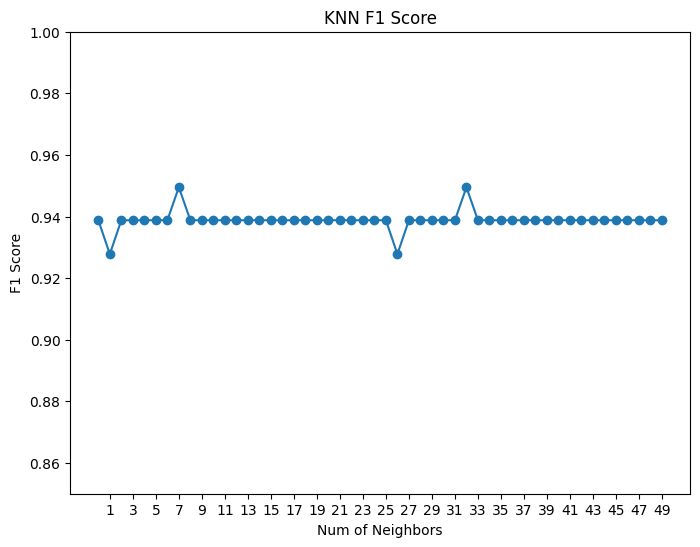

In [32]:
# Plot F1 results
ax = f1_results['F1 Score'].plot(figsize=(8, 6), marker='o')
ax.set(xlabel='Num of Neighbors', ylabel='F1 Score')
ax.set_xticks(range(1, max_k+1, 2));
plt.ylim((0.85, 1))
plt.title('KNN F1 Score')
plt.plot()

A important thing to note from the above plot is the scale of the Y axis F1 Score. It is so small, and each blip shown is probably due to data noise. If we increase the scale and thus zooming out of the plot, we will see a horizontal straight line. This means that the F1 Score is almost the same across all the K values used. This is due to the clean and highly separable dataset which result in the model performing brilliantly across almost all small to medium odd K values. The blips likely due to just one or two individual tumor samples being classified differently.

When we ran our loop to generate the plot, we calculated the F1 score strictly on X_test (which represents a single 20% slice of our data). On that specific 20% slice, $K = 15$ happened to catch a tiny edge case perfectly, giving it that minor peak.

A better way is to use GridSearchCV() which ignores our test set completely during its search. It takes our X_train (the 80% portion) and splits it 5 different ways as shown in the codes below. This gives a more accurate assessment for the value of K with different permutation of datasets.


In [33]:
from sklearn.model_selection import GridSearchCV

# Test a range of K values using 5-fold cross-validation
param_grid = {'n_neighbors': np.arange(1, 51, 2)} # Using only odd numbers
knn_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
knn_cv.fit(X_train, y_train.values.ravel())

print(f"The definitive optimal K is: {knn_cv.best_params_['n_neighbors']}")

The definitive optimal K is: 3


Here, using the GridSearchCV(), result in selecting K = 3. While $K=3$ won the cross-validation F1-score average, low $K$ values can occasionally be twitchy and sensitive to noise. Since the F1 Score is essentially flat, we can pick any K value from 3 and above. However, as mentioned, a low K value makes a Overfitted model, while and high K value result in Underfitted model. We can drill down deeper by investigating the performance on the model's Precision and Recall with the following codes:

In [34]:
# testing out 3 values of K
for k in [3, 15, 31]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train.values.ravel())
    preds = knn.predict(X_test)
    print(f"\n--- Performance for K = {k} ---")
    print(classification_report(y_test, preds))


--- Performance for K = 3 ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        89
           1       0.92      0.94      0.93        48

    accuracy                           0.95       137
   macro avg       0.94      0.95      0.94       137
weighted avg       0.95      0.95      0.95       137


--- Performance for K = 15 ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        89
           1       0.92      0.98      0.95        48

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.96      0.96      0.96       137


--- Performance for K = 31 ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.92      0.96      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96

From the above results, a K value of 15 appears to be the best !

The key take away here is that we need to pay attention to the scale of the Y axis. Like in this case is very small, meaning any tiny difference could be due to data noise. In that case, we need to drill down to observe closely at the precision and recall results. 

## Next steps


Great! Now you have learned about and applied the KNN model to solve a real-world tumor type classification problem. You also tuned the KNN to find the best K value. Later, you will continue learning other popular classification models with different structures, assumptions, cost functions, and application scenarios.


## Authors


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/)


### Other Contributors


<!--## Change Log--!>


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2021-11-9|1.0|Yan|Created the initial version|
|2022-3-29|1.1|Steve Hord|QA Pass|
--!>


Copyright © 2021 IBM Corporation. All rights reserved.
